# Do Discounts Influence Consumer Spending Behavior?

This project aims to analyze consumer spending behavior using a publicly available Black Friday dataset. The study includes exploratory data analysis (EDA), data enrichment, hypothesis testing, and machine learning methods to examine how demographic factors, product categories, and discount-related variables influence purchase amounts. Since the main dataset does not contain direct discount information, an additional e-commerce pricing dataset is incorporated to provide discount-related insights and strengthen the overall study.

Dataset Source

The primary dataset used in this project is the Black Friday dataset, which contains consumer demographic information and purchase records. To enrich the analysis, a supplementary e-commerce pricing dataset is included to provide category-level discount and pricing insights.

## Exploratory Data Analysis (EDA)
This section explores the dataset to understand its structure, key variables, and general patterns in consumer behavior before conducting further analysis.

In [4]:
import pandas as pd

df = pd.read_csv("Black Friday Dataset.csv")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [5]:
df.shape
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


Dataset Overview

The dataset contains 550,068 observations and 12 variables. It includes both categorical and numerical features related to customer demographics and product information. Missing values are present mainly in Product_Category_2 and Product_Category_3, while the purchase variable shows substantial variability across transactions.

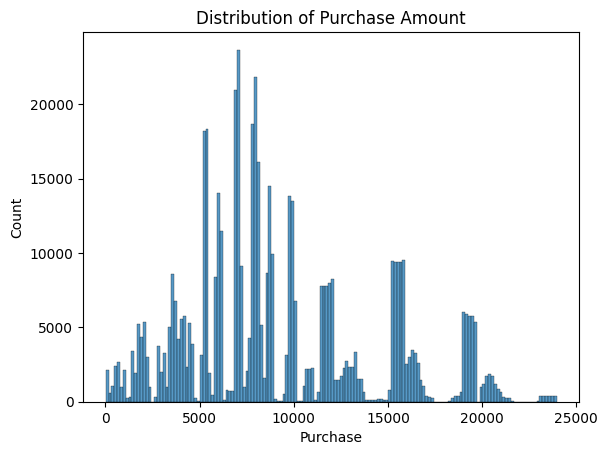

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Purchase"])
plt.title("Distribution of Purchase Amount")
plt.show()

**Distribution of Purchase Amounts**

The distribution of purchase amounts shows that most transactions are concentrated in the lower to mid range, while fewer transactions occur at very high spending levels. This indicates that most customers tend to make moderate purchases.

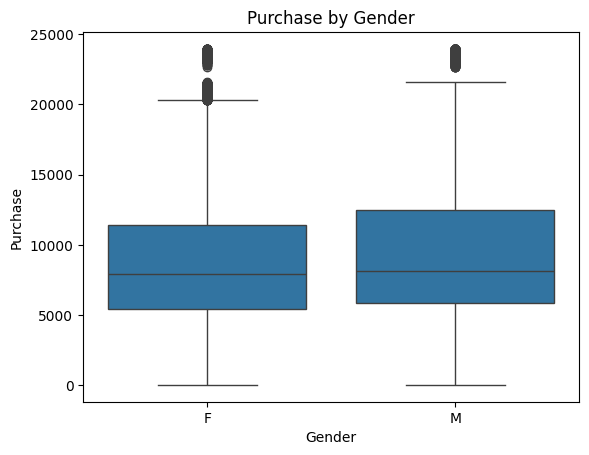

In [ ]:
sns.boxplot(x="Gender", y="Purchase", data=df)
plt.title("Purchase by Gender")
plt.show()

**Analysis of Purchase Amounts by Gender**

The boxplot comparing purchase amounts by gender indicates that male customers have a slightly higher median purchase value than female customers. However, there is a substantial overlap between the distributions, suggesting that the difference is relatively small.

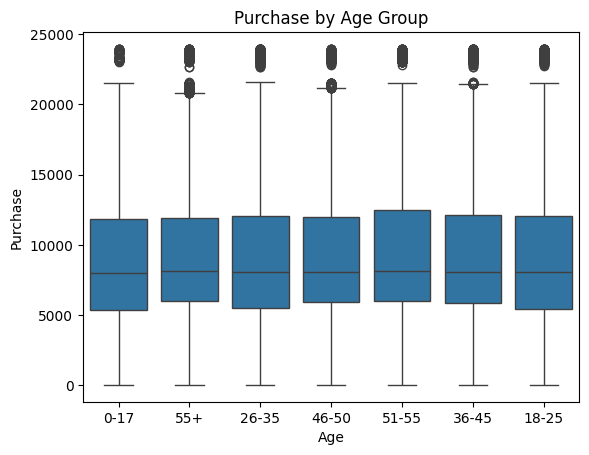

In [ ]:
sns.boxplot(x="Age", y="Purchase", data=df)
plt.title("Purchase by Age Group")
plt.show()

**Analysis of Purchase Amounts by Age Group**

The analysis of purchase amounts across different age groups indicates that some age groups appear to have slightly higher spending levels. However, the differences between groups are not very large, suggesting that age may have a limited effect on consumer spending behavior. Overall, age does not appear to be a primary determinant of consumer spending.

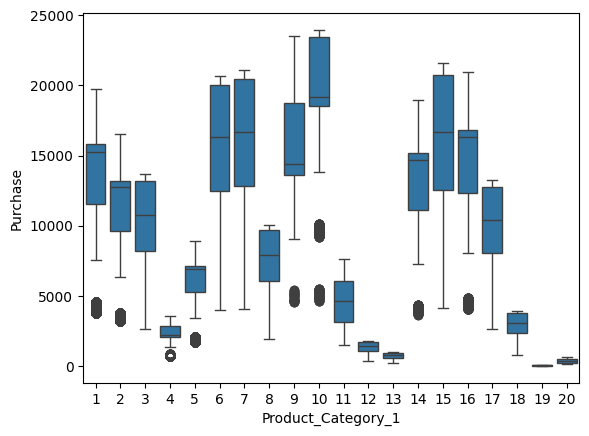

In [ ]:
sns.boxplot(x="Product_Category_1", y="Purchase", data=df)
plt.show()

**Analysis of Purchase Amounts by Product Category**

There is a clear variation in purchase amounts across product categories. Some categories are associated with significantly higher spending levels, suggesting that product type may influence how much customers spend.

**Use of Proxy Variables**

Since the main Black Friday dataset does not include direct discount information, product categories are used as proxy variables to represent potential differences in pricing and discount strategies. Different product categories may naturally have different price ranges and promotional patterns, which can indirectly reflect discount-related effects on consumer spending behavior.

## Data Enrichment

To strengthen the analysis, an additional e-commerce pricing dataset was incorporated as a supplementary data source. The primary Black Friday dataset does not contain direct discount information; therefore, product categories were used as proxy variables for discount-related behavior.

The supplementary dataset provided category-level pricing and discount percentage information. Summary statistics such as average prices and discount levels by product category were examined and compared with the product categories in the Black Friday dataset. This enrichment process helped provide indirect insights into how pricing and discount patterns may influence consumer purchase behavior.

In [6]:
ecom = pd.read_csv("ecommerce_dataset_updated.csv")
ecom.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [7]:
ecommerce_summary = ecom.groupby("Category").agg({
    "Discount (%)":"mean",
    "Price (Rs.)":"mean"
}).reset_index()

ecommerce_summary.head()

,Category,Discount (%),Price (Rs.)
0,Beauty,18.475248,252.738693
1,Books,19.035581,259.123052
2,Clothing,17.919021,263.115913
3,Electronics,19.267068,251.646867
4,Home & Kitchen,19.608379,249.255938


Enrichment Dataset Summary

The additional dataset provides category-level average discount and price information. The results show that discount rates vary across product categories, suggesting that pricing strategies differ between product types. This enriched information supports the assumption that discounts may play an important role in shaping consumer spending behavior.

## Hypothesis Testing

In [8]:
from scipy.stats import ttest_ind

male = df[df["Gender"]=="M"]["Purchase"]
female = df[df["Gender"]=="F"]["Purchase"]

ttest_ind(male, female)

TtestResult(statistic=np.float64(44.837957934353966), pvalue=np.float64(0.0), df=np.float64(550066.0))

**Hypothesis Test: Gender and Purchase Amount**

A t-test was conducted to compare purchase amounts between male and female customers. The results indicate that there is a statistically significant difference between the two groups (p < 0.05), suggesting that gender may influence consumer spending behavior. The extremely small p-value (close to 0) provides strong evidence against the null hypothesis.

In [9]:
from scipy.stats import f_oneway

groups = [df[df["Product_Category_1"] == c]["Purchase"]
          for c in df["Product_Category_1"].unique()]

f_oneway(*groups)

F_onewayResult(statistic=np.float64(50703.97442053582), pvalue=np.float64(0.0))

**Hypothesis Test: Product Category and Purchase Amount**

An ANOVA test was conducted to examine whether purchase amounts differ across all product categories. The results show that there are statistically significant differences between categories (p < 0.05), indicating that product category may influence consumer spending behavior. Therefore, the null hypothesis is rejected.

## Machine Learning Model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

ml_df = df.copy()

categorical_cols = ["Gender", "Age", "City_Category", "Stay_In_Current_City_Years"]

le = LabelEncoder()

for col in categorical_cols:
    ml_df[col] = le.fit_transform(ml_df[col])

ml_df = ml_df.fillna(0)

ml_df = ml_df.sample(50000, random_state=42)

X = ml_df.drop(["User_ID", "Product_ID", "Purchase"], axis=1)
y = ml_df["Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 2247.706802609556
R² Score: 0.6403589400009759


In [11]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
6,Product_Category_1,0.917629
2,Occupation,0.016413
7,Product_Category_2,0.016386
8,Product_Category_3,0.014602
1,Age,0.011554
4,Stay_In_Current_City_Years,0.009331
3,City_Category,0.007832
0,Gender,0.003130
5,Marital_Status,0.003122


Machine Learning Analysis

A Random Forest Regressor was applied to predict purchase amounts using demographic and product-related variables. The model achieved an R² score of approximately 0.64, indicating that it explains a meaningful portion of the variation in purchase amounts. The feature importance results show that Product_Category_1 is the most influential predictor, which supports the earlier EDA and hypothesis testing results that product type plays a major role in consumer spending behavior.

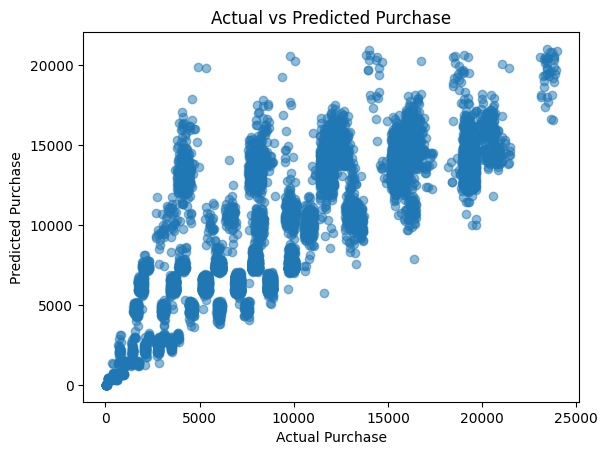

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel("Actual Purchase")
plt.ylabel("Predicted Purchase")
plt.title("Actual vs Predicted Purchase")
plt.show()

Prediction Performance Visualization

The scatter plot compares actual and predicted purchase amounts. The closer the points are to the diagonal trend, the better the model performs. The plot shows that the model captures general spending patterns, although some prediction errors remain.

## Model Comparison

In [13]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression R²:", lr_r2)
print("Random Forest R²:", r2)

Linear Regression R²: 0.1602147076979743
Random Forest R²: 0.6403589400009759


The Random Forest Regressor achieved significantly better predictive performance than the Linear Regression model. While Linear Regression obtained an R² score of approximately 0.16, Random Forest achieved an R² score of about 0.64. This suggests that nonlinear relationships exist between the variables and purchase amounts, making Random Forest more suitable for this dataset.

## Conclusion
The analysis demonstrates that consumer spending behavior is influenced by demographic and product-related factors. Both hypothesis tests showed statistically significant results, with product category having a stronger effect on purchase amounts than gender. Since direct discount information was unavailable, product categories were used as proxy variables, and an additional e-commerce dataset was incorporated to strengthen the analysis. Overall, the findings suggest that pricing and product type are important factors in consumer purchasing behavior. Machine learning results further support these findings by showing that product categories are the strongest predictors of purchase behavior. Future studies using direct discount data may provide more precise insights.